In [3]:
from google.colab import files

#upload the dataset file to Colab
uploaded = files.upload()

Saving global_temps.csv to global_temps.csv


In [4]:
import pandas as pd

#load the dataset
data = pd.read_csv("global_temps.csv")

In [5]:
#check the shape of dataset (number of rows and columns)
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 144
Number of columns: 19


In [6]:
#view the first few rows
print(data.head())

   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1880 -0.19 -0.25 -0.09 -0.17 -0.10 -0.21 -0.18 -0.11 -0.15 -0.24 -0.22   
1  1881 -0.20 -0.15  0.03  0.05  0.05 -0.19  0.00 -0.04 -0.16 -0.22 -0.19   
2  1882  0.16  0.13  0.04 -0.16 -0.14 -0.22 -0.17 -0.08 -0.15 -0.24 -0.17   
3  1883 -0.30 -0.37 -0.13 -0.19 -0.18 -0.08 -0.08 -0.14 -0.23 -0.12 -0.24   
4  1884 -0.13 -0.09 -0.37 -0.40 -0.34 -0.35 -0.31 -0.28 -0.28 -0.25 -0.34   

    Dec   J-D   D-N   DJF   MAM   JJA   SON  
0 -0.18 -0.17   NaN   NaN -0.12 -0.17 -0.20  
1 -0.08 -0.09 -0.10 -0.18  0.04 -0.08 -0.19  
2 -0.36 -0.11 -0.09  0.07 -0.09 -0.16 -0.19  
3 -0.11 -0.18 -0.20 -0.34 -0.17 -0.10 -0.20  
4 -0.31 -0.29 -0.27 -0.11 -0.37 -0.32 -0.29  


In [7]:
#check data types and missing values
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    144 non-null    int64  
 1   Jan     144 non-null    float64
 2   Feb     144 non-null    float64
 3   Mar     144 non-null    float64
 4   Apr     144 non-null    float64
 5   May     144 non-null    float64
 6   Jun     143 non-null    float64
 7   Jul     143 non-null    float64
 8   Aug     143 non-null    float64
 9   Sep     143 non-null    float64
 10  Oct     143 non-null    float64
 11  Nov     143 non-null    float64
 12  Dec     143 non-null    float64
 13  J-D     143 non-null    float64
 14  D-N     142 non-null    float64
 15  DJF     143 non-null    float64
 16  MAM     144 non-null    float64
 17  JJA     143 non-null    float64
 18  SON     143 non-null    float64
dtypes: float64(18), int64(1)
memory usage: 21.5 KB
None


In [8]:
#summary statistics analysis for numerical features to understand their distributions
print(data.describe())

              Year         Jan         Feb         Mar         Apr  \
count   144.000000  144.000000  144.000000  144.000000  144.000000   
mean   1951.500000    0.063333    0.070903    0.088889    0.063681   
std      41.713307    0.423598    0.428513    0.433790    0.396609   
min    1880.000000   -0.810000   -0.630000   -0.630000   -0.580000   
25%    1915.750000   -0.240000   -0.240000   -0.222500   -0.250000   
50%    1951.500000   -0.015000   -0.040000    0.015000   -0.025000   
75%    1987.250000    0.310000    0.382500    0.322500    0.282500   
max    2023.000000    1.180000    1.370000    1.360000    1.130000   

              May         Jun         Jul         Aug         Sep         Oct  \
count  144.000000  143.000000  143.000000  143.000000  143.000000  143.000000   
mean     0.052917    0.033147    0.055874    0.054406    0.058182    0.084196   
std      0.377894    0.367363    0.347531    0.363304    0.360199    0.369290   
min     -0.550000   -0.520000   -0.510000   -

In [9]:
!pip install matplotlib seaborn

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
print(data.columns)

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON'],
      dtype='object')


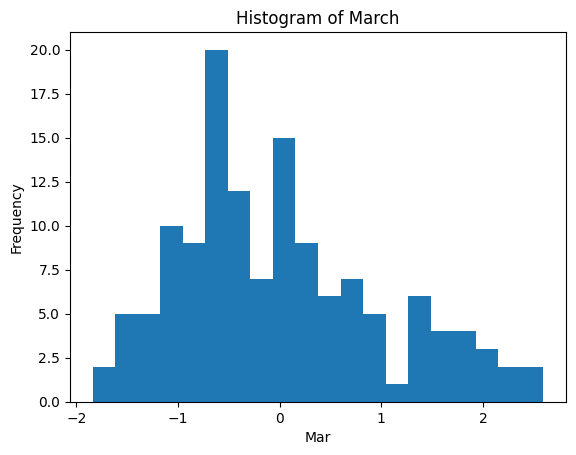

In [28]:
#histogram for the 'Mar' column
plt.hist(data['Mar'], bins=20)
plt.xlabel('Mar')
plt.ylabel('Frequency')
plt.title('Histogram of March')
plt.show()

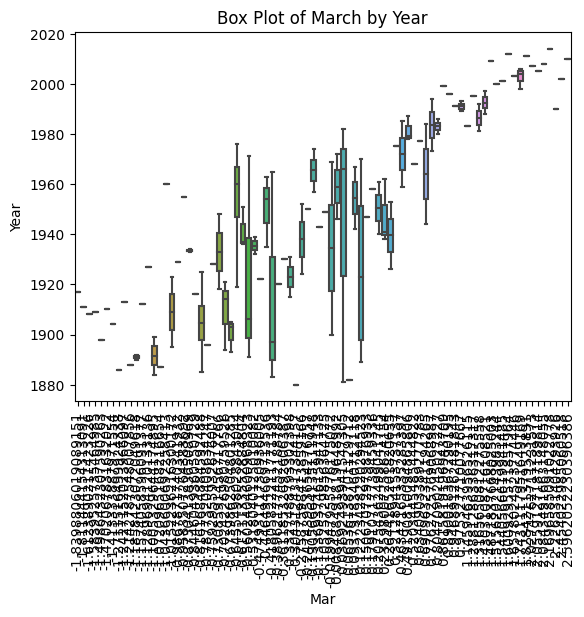

In [35]:
#box plot for the 'Mar' column by 'Year'
sns.boxplot(x='Mar', y='Year', data=data)
plt.xlabel('Mar')
plt.ylabel('Year')
plt.title('Box Plot of March by Year')
plt.xticks(rotation=90)  #rotating x-axis labels for better readability(didn't help much)
plt.show()

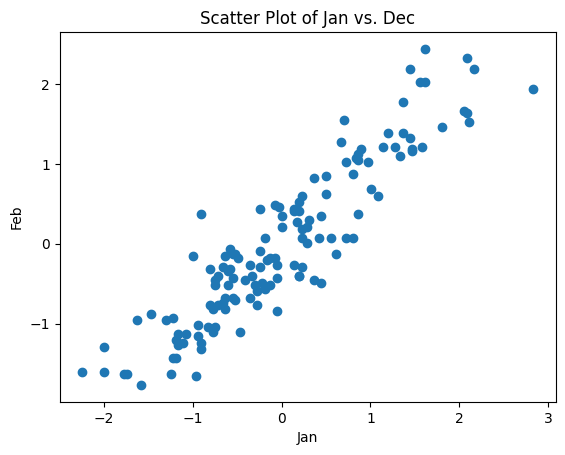

In [38]:
#scatter plot to visualize the relationship between 'Jan' and 'Feb'
plt.scatter(data['Jan'], data['Feb'])
plt.xlabel('Jan')
plt.ylabel('Feb')
plt.title('Scatter Plot of Jan vs. Feb')
plt.show()

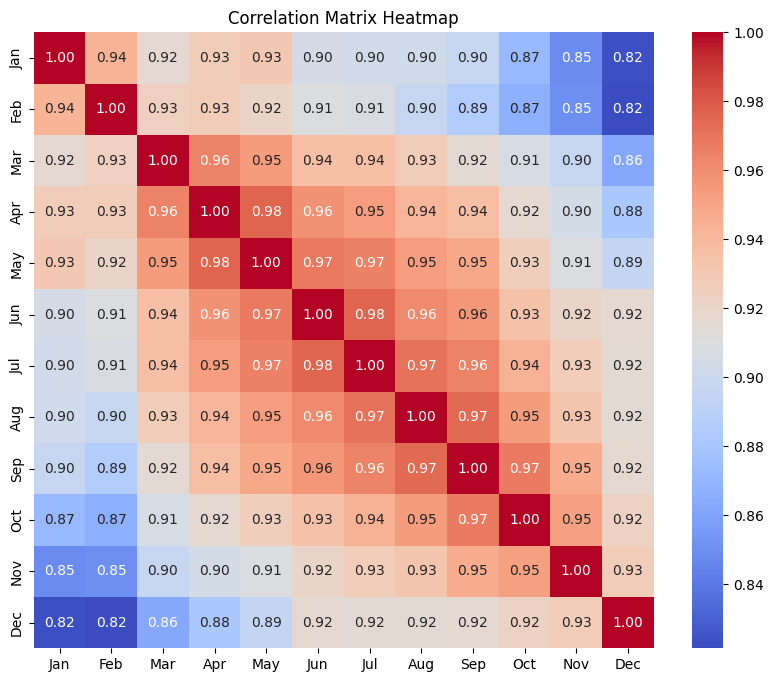

In [15]:
#calculate the correlation matrix
correlation_matrix = data[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].corr()

#visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [16]:
#check for missing data
missing_data = data.isnull().sum()
print("Missing Data:\n", missing_data)

#handle missing data (example: imput with the mean)
data.fillna(data.mean(), inplace=True)

Missing Data:
 Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     1
Jul     1
Aug     1
Sep     1
Oct     1
Nov     1
Dec     1
J-D     1
D-N     2
DJF     1
MAM     0
JJA     1
SON     1
dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
import numpy as np

In [40]:
#address outliers (e.g., use appropriate method)
# this dataset doesn't have categorical columns only numerical ones
# data = pd.get_dummies(data, columns=['categorical_column'], drop_first=True)

#handle categorical variables
# Q1 = data.quantile(0.25)
# Q3 = data.quantile(0.75)
# IQR = Q3 - Q1
# data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

#scale or normalize numerical features
scaler = StandardScaler()
numerical_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data.loc[:, numerical_columns] = scaler.fit_transform(data[numerical_columns])

#split the dataset into training and testing sets
X = data.drop('Year', axis=1)
y = data['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
 # Machine Learning

In [20]:
X = data.drop("Year", axis=1)
y = data["Year"]

In [41]:
from sklearn.linear_model import LinearRegression  #example model

#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#create and train your machine learning model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Absolute Error: 17.0459080265623
Mean Squared Error: 486.2024470565759
R-squared: 0.6243412074950782


In [23]:
# In conclusion, I am scared and I want to go home ft. Jonny Depp
#